# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: 
- _Student No._: 20XX-XXXXX
- _Section_: THR-TX-X

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.


### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

> Before we proceed, let us find the analytic derivative of f
> $$
\begin{align}
    f'(x) &= -5x^4 + 16x^3 - 12x^2 + x^2 e^x + 2xe^x - 4x - 4xe^x - 4e^x + 8 + 4e^x \\
          &= -5x^4 + 16x^3 - 12x^2 + x^2 e^x - 2xe^x - 4x + 8 
\end{align}
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tolerance = 1e-8

def f(x):
    return (-x**5) + (4*x**4) - (4*x**3) + (x**2*np.exp(x)) - (2*x**2) - (4*x*np.exp(x)) + (8*x) + (4*np.exp(x)) - 8 

def fp(x):
    return (-5*x**4) + (16*x**3) - (12*x**2) + (x**2 * np.exp(x)) - (2*x*np.exp(x)) - (4*x) + 8 

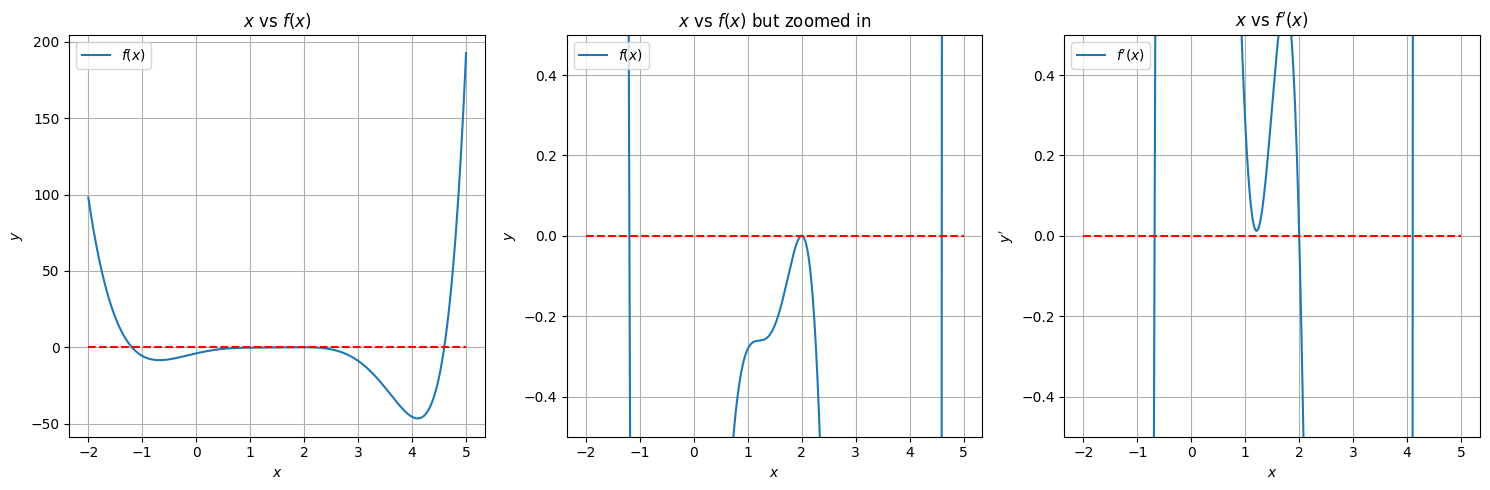

In [4]:
fig, [ax1, ax2, ax3] = plt.subplots(1,3,figsize=(15,5))

x = np.linspace(-2, 5, 1000)
y_0 = np.zeros(len(x))

ax1.plot(x, f(x), label='$f(x)$')
ax1.plot(x, y_0, color='red', ls='--')
ax1.legend(loc='upper left')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.grid(True)
ax1.set_title('$x$ vs $f(x)$')

ax2.plot(x, f(x), label='$f(x)$')
ax2.plot(x, y_0, color='red', ls='--')
ax2.legend(loc='upper left')
ax2.set_ylim(-0.5,0.5)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.grid(True)
ax2.set_title('$x$ vs $f(x)$ but zoomed in')

ax3.plot(x, fp(x), label="$f'(x)$")
ax3.plot(x, y_0, color='red', ls='--')
ax3.legend(loc='upper left')
ax3.set_ylim(-0.5,0.5)
ax3.set_xlabel('$x$')
ax3.set_ylabel("$y'$")
ax3.grid(True)
ax3.set_title(r"$x$ vs $f'(x)$")

plt.tight_layout()
plt.show()

### Fixed Point:

We first rearrange $f(x)=0$ to the form $x = g(x)$.

$$
\begin{align}
    f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8 &= 0 \\
    -x^5 + 4x^4 - 4x^3 -4xe^x + 8x + 4e^x -8 &= x^2 (2-e^x) \\
    \frac{-x^5 + 4x^4 - 4x^3 -4xe^x + 8x + 4e^x -8}{2-e^x} &= x^2 \\
    \sqrt{\frac{-x^5 + 4x^4 - 4x^3 -4xe^x + 8x + 4e^x -8}{2-e^x}} &= x
\end{align}
$$

It follows that
$$
g(x) = \sqrt{\frac{-x^5 + 4x^4 - 4x^3 -4xe^x + 8x + 4e^x -8}{2-e^x}}
$$

Note that we cannot find roots below $ln(2)$ 

In [178]:
def g(x):
    return np.sqrt(((-x**5) + (4*x**4) - (4*x**3) - (4*x*np.exp(x)) + (8*x) + (4*np.exp(x)) - 8)/(2-np.exp(x)))
    
def fixed_point(function=f, x=x_start, k=100, tolerance=tolerance):
    x_guess = [x] # we put x_0 for plotting purposes 
    x_old = x
    print(f"Initial Guess: {x_old}")
    for i in range(1, k):
        #print(x_old)
        x_new = function(x_old)
        #print(x_new)
        x_guess.append(x_new)
        x_diff = x_new - x_old
        if abs(x_diff/x_new) < tolerance: # we stop if the change is below the tolerance
            break
        x_old = x_new
    else:
        x_new = None
        
    return x_guess
    
zeros = fixed_point(function=g, x=1.1, k=10000)
# print(zero)
print(f"Final Result: {zeros[-1]}")

Initial Guess: 1.1
Final Result: 1.9991760007064214


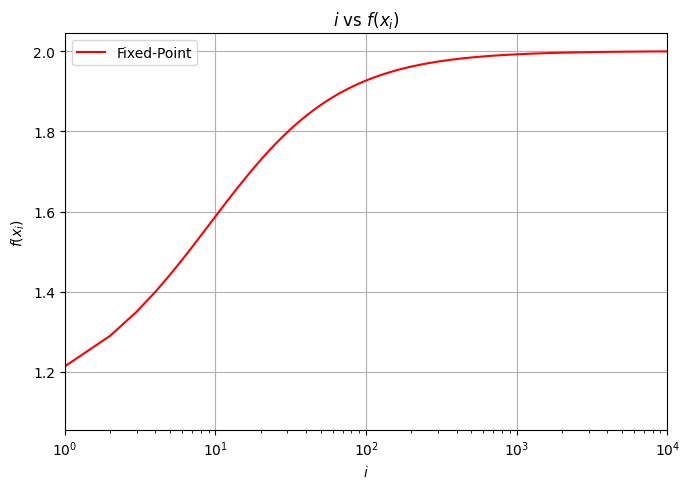

In [161]:
fig, ax1 = plt.subplots(figsize=(7,5))

x_fp = np.linspace(0, len(zeros)-1, len(zeros))
y_fp = zeros

ax1.semilogx(x_fp, y_fp, color='red', ls='-', label='Fixed-Point')
ax1.legend()
ax1.set_xlabel('$i$')
ax1.set_ylabel('$f(x_i)$')
ax1.set_xlim(1,1e4)
ax1.grid(True)
ax1.set_title('$i$ vs $f(x_i)$')
plt.tight_layout()

### Bisection Method:

We first start with a boundary and determine whether the product between each boundary and the midpoint is negative.

In [225]:
def bisection_method(function=f, x_0=0, x_1=2, k=1000, tolerance=tolerance):
    f_0 = f(x_0)
    x_guess = [(x_0 + x_1)/2]
    for i in range(1, k):
        x_2 = (x_0 + x_1)/2
        f_2 = f(x_2)
        
        if f_0 * f_2 < 0:
            x_1 = x_2
        else:
            x_0, f_0 = x_2, f_2

        x_2_updated = (x_0 + x_1)/2
        x_diff = abs(x_2_updated - x_2)

        x_guess.append(x_2_updated)

        if abs(x_diff/x_2_updated) < tolerance:
            break

    else: 
        x_2_updated = None

    return x_guess

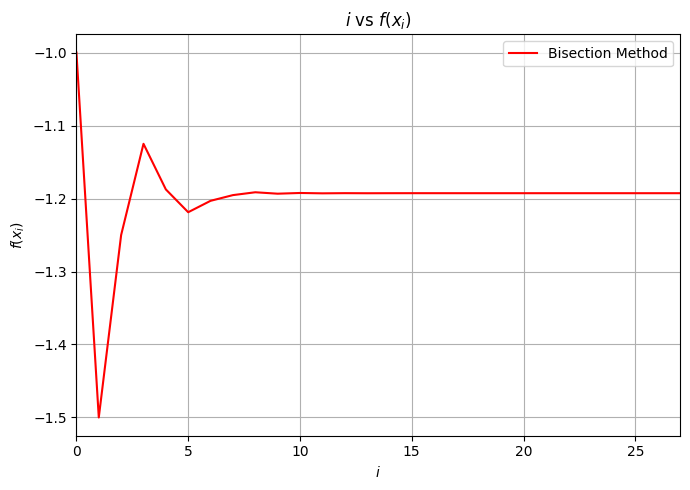

In [227]:
zeros = bisection_method(function=f, x_0=-2, x_1=0, k=10000)

fig, ax1 = plt.subplots(figsize=(7,5))

x_bm = np.linspace(0, len(zeros)-1, len(zeros))
y_bm = zeros

ax1.plot(x_bm, y_bm, color='red', ls='-', label='Bisection Method')
ax1.legend()
ax1.set_xlabel('$i$')
ax1.set_ylabel('$f(x_i)$')
ax1.set_xlim(0,len(zeros)-1)
ax1.grid(True)
ax1.set_title('$i$ vs $f(x_i)$')
plt.tight_layout()

### Newthon-Rhapson Method:

We already obtained the analytical derivative.

In [208]:
def newton_rhapson(function=f, derivative=fp, x_initial=0, k=1000, tolerance=tolerance):
    zeros = [x_initial]
    x_diff = tolerance + 1
    x_new = 1 # we just initialize these variables to be greater than the tolerance
    i = 1
    while abs(x_diff/x_new) > tolerance and i < k:
        x_new = x_initial - f(x_initial)/fp(x_initial)
        x_diff = x_new - x_initial
        zeros.append(x_new)
        x_initial = x_new
    return zeros

Obtained Root: 1.9999999480144195


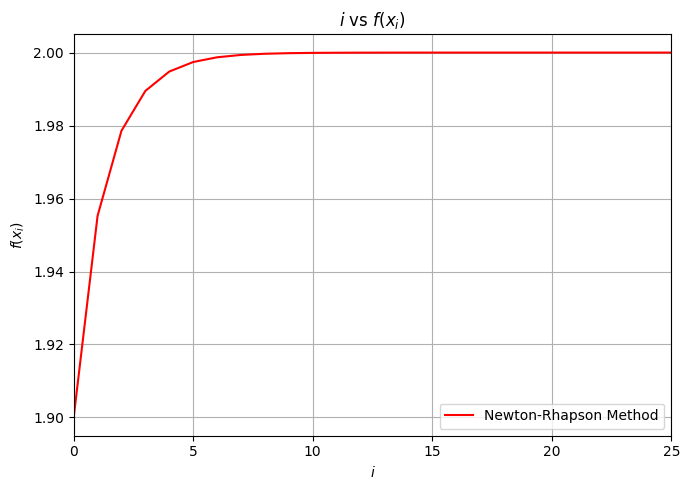

In [221]:
zeros = newton_rhapson(x_initial = 1.9)

print(f"Obtained Root: {zeros[-1]}")

fig, ax1 = plt.subplots(figsize=(7,5))

x_bm = np.linspace(0, len(zeros)-1, len(zeros))
y_bm = zeros

ax1.plot(x_bm, y_bm, color='red', ls='-', label='Newton-Rhapson Method')
ax1.legend(loc='lower right')
ax1.set_xlabel('$i$')
ax1.set_ylabel('$f(x_i)$')
ax1.set_xlim(0,len(zeros)-1)
ax1.grid(True)
ax1.set_title('$i$ vs $f(x_i)$')
plt.tight_layout()

In [ ]:
def secant(function=f, derivative=fp, x_0=0, x_1=1, k=1000, tolerance=tolerance)

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---